# PredictiveSense AI 🚀
## Day 6 - Anomaly Detection
### Isolation Forest — Real Time Sensor Anomaly Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load cleaned dataset
df = pd.read_csv(r'C:\Users\vipin nagar\OneDrive\Desktop\Internship 2026\PredictiveSense-AI\data\processed\train_final.csv')

print("✅ Data loaded!")
print(f"Shape: {df.shape}")

✅ Data loaded!
Shape: (20631, 21)


In [2]:
from sklearn.ensemble import IsolationForest

# Sensor columns select karo
sensor_cols = [col for col in df.columns if 'sensor' in col]

# Isolation Forest model
iso_forest = IsolationForest(
    contamination=0.05,  # 5% data anomalous maano
    random_state=42,
    n_jobs=-1
)

# Train karo
iso_forest.fit(df[sensor_cols])

# Predict karo — -1 = anomaly, 1 = normal
df['anomaly'] = iso_forest.predict(df[sensor_cols])

# Count
total     = len(df)
anomalies = (df['anomaly'] == -1).sum()
normal    = (df['anomaly'] == 1).sum()

print("✅ Isolation Forest trained!")
print(f"Total records : {total}")
print(f"Normal        : {normal}")
print(f"Anomalies     : {anomalies}")
print(f"Anomaly %     : {anomalies/total*100:.2f}%")

✅ Isolation Forest trained!
Total records : 20631
Normal        : 19599
Anomalies     : 1032
Anomaly %     : 5.00%


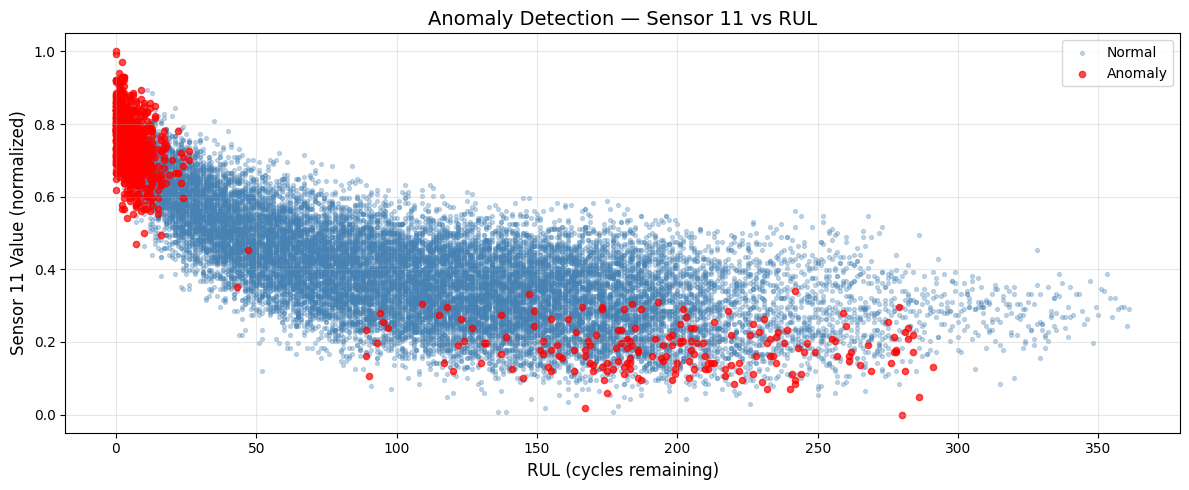

In [3]:
# Anomalies vs RUL — kab zyada anomalies aati hain?
plt.figure(figsize=(12, 5))

normal_data   = df[df['anomaly'] == 1]
anomaly_data  = df[df['anomaly'] == -1]

plt.scatter(normal_data['RUL'],  normal_data['sensor_11'],
            c='steelblue', alpha=0.3, s=8, label='Normal')
plt.scatter(anomaly_data['RUL'], anomaly_data['sensor_11'],
            c='red', alpha=0.7, s=20, label='Anomaly')

plt.title('Anomaly Detection — Sensor 11 vs RUL', fontsize=14)
plt.xlabel('RUL (cycles remaining)', fontsize=12)
plt.ylabel('Sensor 11 Value (normalized)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

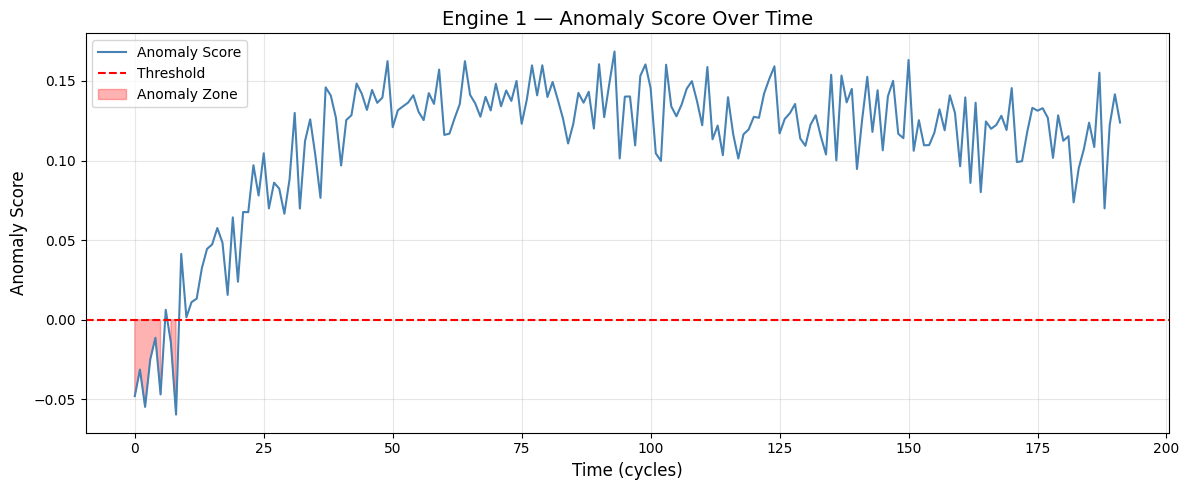

In [4]:
# Anomaly score — kitna anomalous hai har record
df['anomaly_score'] = iso_forest.decision_function(df[sensor_cols])
# Score negative = zyada anomalous, positive = normal

plt.figure(figsize=(12, 5))
plt.plot(df[df['unit_id']==1]['RUL'].values[::-1],
         df[df['unit_id']==1]['anomaly_score'].values[::-1],
         color='steelblue', linewidth=1.5, label='Anomaly Score')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Threshold')
plt.fill_between(range(len(df[df['unit_id']==1])),
                 df[df['unit_id']==1]['anomaly_score'].values[::-1],
                 0, where=(df[df['unit_id']==1]['anomaly_score'].values[::-1] < 0),
                 color='red', alpha=0.3, label='Anomaly Zone')
plt.title('Engine 1 — Anomaly Score Over Time', fontsize=14)
plt.xlabel('Time (cycles)', fontsize=12)
plt.ylabel('Anomaly Score', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
import pickle
import os

# Save anomaly detection model
with open(r'C:\Users\vipin nagar\OneDrive\Desktop\Internship 2026\PredictiveSense-AI\models\iso_forest.pkl', 'wb') as f:
    pickle.dump(iso_forest, f)

print("✅ Isolation Forest model saved!")
print("📁 Location: models/iso_forest.pkl")
print(f"\n=== DAY 6 SUMMARY ===")
print(f"Total Records  : 20,631")
print(f"Anomalies Found: 1,032 (5%)")
print(f"Key Finding    : Anomalies peak near RUL=0 (failure zone)")
print(f"Top Sensor     : sensor_11 shows highest anomaly concentration")

✅ Isolation Forest model saved!
📁 Location: models/iso_forest.pkl

=== DAY 6 SUMMARY ===
Total Records  : 20,631
Anomalies Found: 1,032 (5%)
Key Finding    : Anomalies peak near RUL=0 (failure zone)
Top Sensor     : sensor_11 shows highest anomaly concentration
